Group Project

Authors: Nathaniel Wan, Jana Abdelmonem 

(we couldn't get the pull thing to work so we just coded on Nathaniel's laptop)

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

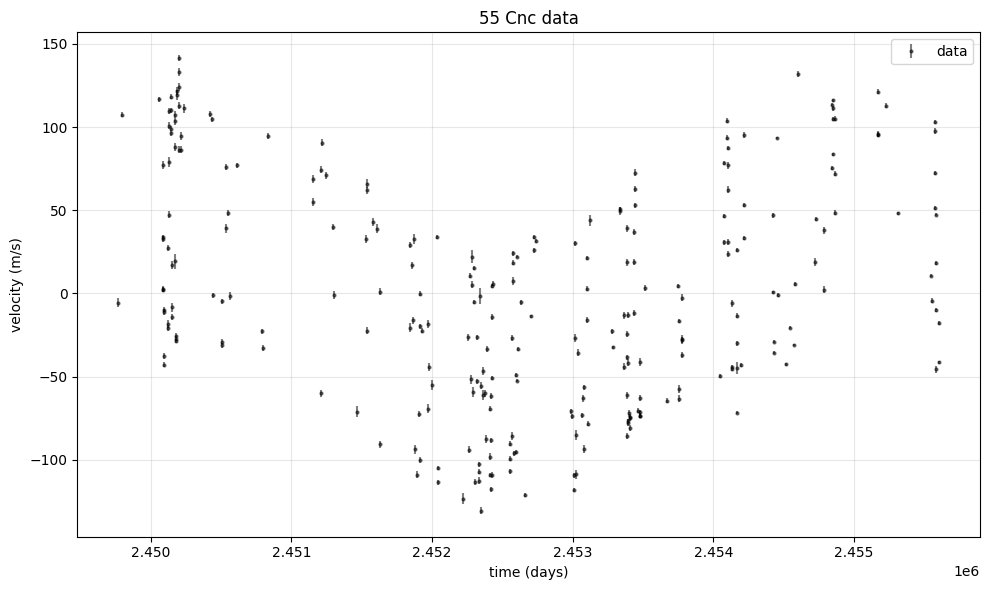

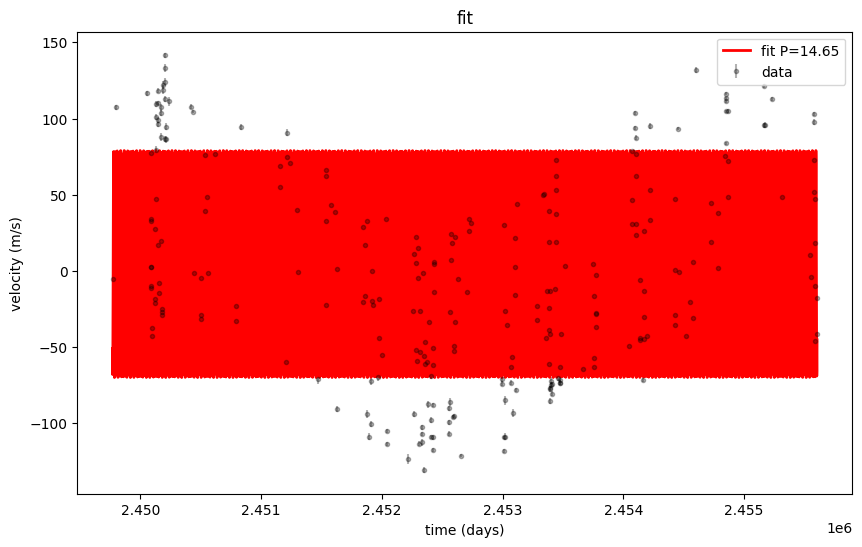

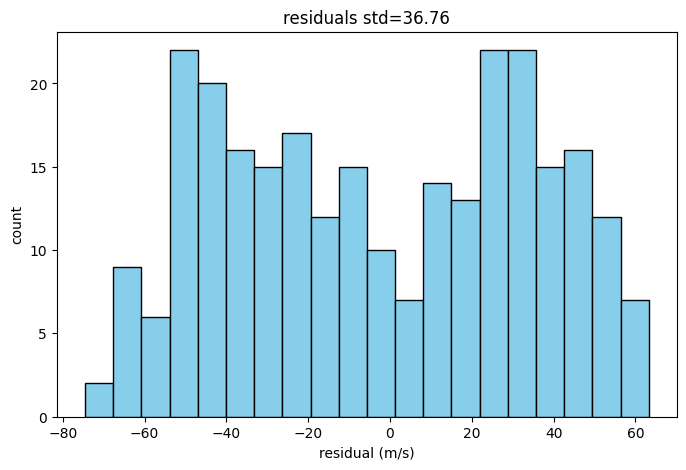

55 Cnc stuff
period: 14.652 days
K: 74.49 m/s
mass: 0.843 Mjup

residual std: 36.76
avg err: 1.79

other identified planets:
55 Cnc c ~44 d
55 Cnc f ~260 d
55 Cnc d ~4800 d
55 Cnc e ~0.7 d


In [5]:
data = np.genfromtxt("group_project_data.txt", skip_header=24)
t, rv, rv_err = data[:, 0], data[:, 1], data[:, 2]

plt.figure(figsize=(10,6))
plt.errorbar(t, rv, yerr=rv_err, fmt='k.', markersize=4, alpha=0.5, label="data")
plt.xlabel("time (days)")
plt.ylabel("velocity (m/s)")
plt.title("55 Cnc data")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

other_planets = {
    "55 Cnc c": "~44 d",
    "55 Cnc f": "~260 d",
    "55 Cnc d": "~4800 d",
    "55 Cnc e": "~0.7 d"
}

def model(t, K, P, phi, offset):
    return K * np.sin(2 * np.pi * t / P + phi) + offset

popt, pcov = curve_fit(
    model, t, rv,
    p0=[70, 14.65, 0, np.mean(rv)],
    sigma=rv_err,
    absolute_sigma=True,
    maxfev=20000,
    bounds=([0, 14.0, -np.inf, -np.inf], [150, 15.0, np.inf, np.inf])
)

K_fit, P_fit, phi_fit, off_fit = popt

t_plot = np.linspace(t.min(), t.max(), 5000)
rv_plot = model(t_plot, *popt)

plt.figure(figsize=(10,6))
plt.errorbar(t, rv, yerr=rv_err, fmt='k.', alpha=0.3, label="data")
plt.plot(t_plot, rv_plot, 'r-', linewidth=2, label=f"fit P={P_fit:.2f}")
plt.xlabel("time (days)")
plt.ylabel("velocity (m/s)")
plt.title("fit")
plt.legend()
plt.show()

residuals = rv - model(t, *popt)
res_std = np.std(residuals)
mean_inst_err = np.mean(rv_err)

plt.figure(figsize=(8,5))
plt.hist(residuals, bins=20, color='skyblue', edgecolor='black')
plt.xlabel("residual (m/s)")
plt.ylabel("count")
plt.title(f"residuals std={res_std:.2f}")
plt.show()

M_star = 0.91
M_jup = (abs(K_fit)/28.4) * (P_fit/365)**(1/3) * (M_star)**(2/3)

print("55 Cnc stuff")

print("period:", round(P_fit,3), "days")
print("K:", round(K_fit,2), "m/s")
print("mass:", round(M_jup,3), "Mjup")

print("\nresidual std:", round(res_std,2))
print("avg err:", round(mean_inst_err,2))

print("\nother identified planets:")
for name, info in other_planets.items():
    print(name, info)

The planet is 55 Cancri 